# Graph Neural Network


<b> Objective: </b>
Test whether a learned aggregation over the neighbourhood beats the hand-specified KNN columns

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>

In [1]:
#Colab has torch already; torch_geometric needs installing on a fresh runtime
!pip install -q torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 980.3 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.5 MB/s eta 0:00:00a 0:00:01


### Imports

In [2]:
import sys
import os
COLAB_SESSION = True

if COLAB_SESSION:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DRIVE_PATH = "/content/drive/MyDrive/UCPH/POOCS/"
    sys.path.insert(0, DRIVE_PATH)      # so GreenlandUtils.py is importable
else:
    DRIVE_PATH = ""

import pandas as pd
import numpy as np
import warnings
import json
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv, GATConv

from GreenlandUtils import lonlatToUTM24N, Split, MostCommonElements, Printable

torch.manual_seed(42)
np.random.seed(42)

#Colab with a GPU runtime picks this up automatically; locally it falls back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}   device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
torch 2.11.0+cu128   device: cuda
   Tesla T4


### Setup

Reads the same `Data.csv`, the same folds and the same column schema as the regressor
notebook, so the two sets of numbers are directly comparable.

To run on Colab with a GPU runtime, set `COLAB_SESSION = True` above and mirror these under
`DRIVE_PATH` on Drive:

```
GreenlandUtils.py
Data/<source>.json
Data/<DATA_TYPE>/<MERGE_TYPE>/Data.csv
Data/<DATA_TYPE>/<MERGE_TYPE>/5-Fold.kfold
Results/<DATA_TYPE>/<MERGE_TYPE>/          (for the baseline and KNN C json to compare against)
```

In [3]:
DATA_TYPE = "Stream Sediment"
MERGE_TYPE = "Mean Merge"
SOURCE_CSV = "stream-sediment"

DATA_PATH = f"Data/{DATA_TYPE}/{MERGE_TYPE}/"
RESULTS_PATH = f"Results/{DATA_TYPE}/{MERGE_TYPE}/"
os.makedirs(f"{DRIVE_PATH}{RESULTS_PATH}", exist_ok=True)


def ReadColumnSchema(baseName: str) -> dict:
    with open(f"{DRIVE_PATH}Data/{baseName}.json", "r") as f:
        return json.load(f)

def ReadDataFrame(path: str, baseName: str) -> pd.DataFrame:
    return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")

def ReadKFold(path: str, baseName: str, df: pd.DataFrame) -> list[Split]:
    with open(f"{DRIVE_PATH}{path}{baseName}.kfold", "r") as f:
        json_result = json.load(f)

    return [Split({name: df.loc[idx] for name, idx in json_result[key].items()}) for key in sorted(json_result, key=int)]

def SaveResults(results: dict, path: str, baseName: str):
    for _, score in results.items():
        if "y_pred" in score:
            score["y_pred"] = score["y_pred"].tolist() if not isinstance(score["y_pred"], list) else score["y_pred"]
        if "y_test" in score:
            score["y_test"] = score["y_test"].tolist() if not isinstance(score["y_test"], list) else score["y_test"]

    with open(f"{DRIVE_PATH}{path}{baseName}.json", "w") as f:
        json.dump(results, f, indent=4)

def LoadResults(path: str, baseName: str) -> dict:
    results = None
    try:
        with open(f"{DRIVE_PATH}{path}{baseName}.json", "r") as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"File not found: {DRIVE_PATH}{path}{baseName}.json")
    return results

def AggregateFolds(kfoldResults: dict):
    aggregated = {}

    for element, folds in kfoldResults.items():
        valid = [s for s in folds.values() if s["r2"] is not None and not np.isnan(s["r2"])]
        if not valid:
            aggregated[element] = { "r2": None, "mae": None }
            continue

        aggregated[element] = {
            "r2": float(np.mean([s["r2"] for s in valid])),
            "r2_std": float(np.std([s["r2"] for s in valid])),
            "mae": float(np.mean([s["mae"] for s in valid])),
        }

    return aggregated


df = ReadDataFrame(DATA_PATH, "Data")
kfold_splits = ReadKFold(DATA_PATH, "5-Fold", df)

schema = ReadColumnSchema(SOURCE_CSV)
sampleCol = schema["sampleCol"]
metaCols = schema["metaCols"]
physicalCols = schema["physicalCols"]
locationCols = schema["locationCols"]

elementCols = [col for col in df.columns if col not in metaCols + physicalCols]

MIN_COVERAGE = 10
coverage = df[elementCols].notna().sum()
elementCols = [col for col in elementCols if coverage[col] >= MIN_COVERAGE]

mostCommonElements = [element for element, _ in MostCommonElements(df, elementCols, top_n=10)]

elementsToTrain = [col for col in elementCols if coverage[col] >= 1000]

print(f"Samples: {len(df)}   Elements: {len(elementCols)}   Folds: {len(kfold_splits)}")
print(f"Targets: {mostCommonElements}")
print(f"{len(elementsToTrain)} Targets: {elementsToTrain}")

/tmp/ipykernel_700/76896644.py:15: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")
Analyzing Elements: 100%|██████████| 87/87 [00:00<00:00, 6872.93it/s]

Samples: 17463   Elements: 87   Folds: 5
Targets: ['Zn ppm', 'U ppm', 'Cu ppm', 'Rb ppm', 'Ba ppm', 'Cr ppm', 'Sr ppm', 'Fe %', 'V ppm', 'Co ppm']
71 Targets: ['SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3t wt%', 'Fe2O3 wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'Sum wt%', 'L.o.i. wt%', 'Ag ppm', 'Al %', 'As ppm', 'Ba ppm', 'Be ppm', 'Ca %', 'Cd ppm', 'Co ppm', 'Cr ppm', 'Cu ppm', 'Fe %', 'Hf ppm', 'K %', 'Mg %', 'Mn ppm', 'Mo ppm', 'Na %', 'Nb ppm', 'Ni ppm', 'P %', 'Pb ppm', 'Rb ppm', 'S %', 'Sb ppm', 'Sn ppm', 'Sr ppm', 'Ta ppm', 'Th ppm', 'Ti %', 'V ppm', 'W ppm', 'Zn ppm', 'Zr ppm', 'Sc ppm', 'Y ppm', 'La ppm', 'Ce ppm', 'Au ppb', 'Br ppm', 'Cs ppm', 'U ppm', 'Nd ppm', 'Sm ppm', 'Eu ppm', 'Tb ppm', 'Yb ppm', 'Lu ppm', 'Ga ppm', 'Ge ppm', 'Tl ppm', 'Pr ppm', 'Gd ppm', 'Dy ppm', 'Ho ppm', 'Er ppm', 'Tm ppm', 'Mn %', 'Cl %']


### Building the Graph

One node per sample. Edges join a sample to its `k` nearest **training** neighbours, exactly
the mapping the KNN variants use, so the graph the network sees is the same neighbourhood the
hand-built columns saw.

Node features are split in two, which is what makes the comparison fair:

* **`xSelf`** — the sample's own elements with the target removed. This is what the node
  contributes to *its own* prediction, so the target can never appear here.
* **`xMessage`** — what a node broadcasts along its edges. With `TARGET_CHANNEL` on it
  additionally carries the target element, populated on **training rows only**.

That second channel matters. The hand-built variant C includes `k-KNN_<target>_mean`, the
neighbours' mean of the target itself — and variant A, which is *only* that column, recovers
about two thirds of C's entire gain. Dropping the target from every node, as an earlier version
of this notebook did, left the graph strictly less informed than the tabular model it was being
compared against.

Each element still contributes two numbers: the standardised value (zero when absent) and a
present/absent flag, since a network cannot consume NaN and needs to tell "average" apart from
"not measured".

In [4]:
def ProjectedCoords(df: pd.DataFrame, lonCol: str = "Longitude", latCol: str = "Latitude") -> np.ndarray:
    x, y = lonlatToUTM24N(df[lonCol].to_numpy(dtype=float), df[latCol].to_numpy(dtype=float))
    return np.column_stack([x, y])


def BuildNeighbourMapping(df: pd.DataFrame, split: Split, k: int = 20, excludeSameLocation: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """Identical to the regressor notebook: neighbours come from the training rows only."""

    allCoords = ProjectedCoords(df)
    trainPos = df.index.get_indexer(split.data["train"].index)
    trainCoords = allCoords[trainPos]

    padding = int(df.groupby(["Longitude", "Latitude"]).size().max()) if excludeSameLocation else 1
    nNeighbours = min(k + padding, len(trainPos))

    tree = NearestNeighbors(n_neighbors=nNeighbours).fit(trainCoords)
    distances, positions = tree.kneighbors(allCoords)
    neighbourPos = trainPos[positions]

    rejected = neighbourPos == np.arange(len(df))[:, None]
    if excludeSameLocation:
        rejected |= distances == 0

    distances = np.where(rejected, np.inf, distances)
    ordered = np.argsort(distances, axis=1)[:, :k]

    return np.take_along_axis(neighbourPos, ordered, axis=1), np.take_along_axis(distances, ordered, axis=1)


def BuildEdges(neighbourPos: np.ndarray, neighbourDist: np.ndarray, k: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Directed edges neighbour -> sample, carrying log distance in km as the edge feature."""

    source = neighbourPos[:, :k].ravel()
    target = np.repeat(np.arange(len(neighbourPos)), k)
    distance = neighbourDist[:, :k].ravel()

    #A sample with fewer than k reachable neighbours keeps infinite distances, so drop those
    usable = np.isfinite(distance)

    edgeIndex = torch.tensor(np.vstack([source[usable], target[usable]]), dtype=torch.long, device=DEVICE)

    #Log scale because neighbour distance spans metres to tens of km
    edgeAttr = torch.tensor(np.log1p(distance[usable] / 1000.0), dtype=torch.float32, device=DEVICE).unsqueeze(1)

    return edgeIndex, edgeAttr


def Standardise(values: np.ndarray, trainPos: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Zero-mean unit-variance on the training rows, plus a present/absent flag per column."""

    #Statistics come from the training rows so a test sample never informs the scaling
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        centre = np.nanmean(values[trainPos], axis=0)
        spread = np.nanstd(values[trainPos], axis=0)

    spread = np.where((spread == 0) | ~np.isfinite(spread), 1.0, spread)
    centre = np.where(np.isfinite(centre), centre, 0.0)

    present = np.isfinite(values).astype(np.float32)
    scaled = np.where(np.isfinite(values), (values - centre) / spread, 0.0)

    return scaled, present


def BuildNodeFeatures(df: pd.DataFrame, elementCols: list[str], element: str, trainPos: np.ndarray,
                      includeTargetChannel: bool = False) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """What a node keeps for itself, and what it broadcasts to its neighbours.

    Returns (xSelf, xMessage, y). xSelf never contains the target, because it feeds the node's
    own prediction. xMessage may carry the target, populated on training rows only, which is
    the information variant C reads out of its neighbourhood.
    """

    featureCols = [col for col in elementCols if col != element]
    scaled, present = Standardise(df[featureCols].to_numpy(dtype=float), trainPos)
    selfFeatures = np.hstack([scaled, present])

    xSelf = torch.tensor(selfFeatures, dtype=torch.float32, device=DEVICE)
    y = torch.tensor(df[element].to_numpy(dtype=float), dtype=torch.float32, device=DEVICE)

    if not includeTargetChannel:
        return xSelf, xSelf, y

    targetScaled, targetPresent = Standardise(df[[element]].to_numpy(dtype=float), trainPos)

    #Only training rows may broadcast their target: a test sample's own value must not reach
    #any model input, and variant C likewise averages over training neighbours only
    broadcast = np.zeros((len(df), 1), dtype=bool)
    broadcast[trainPos] = True
    targetScaled = np.where(broadcast, targetScaled, 0.0)
    targetPresent = np.where(broadcast, targetPresent, 0.0)

    xMessage = torch.tensor(np.hstack([selfFeatures, targetScaled, targetPresent]),
                            dtype=torch.float32, device=DEVICE)

    return xSelf, xMessage, y


#Switching this off reproduces the earlier, target-blind runs; the cache names below carry a
#suffix so the two sets of results never overwrite one another
TARGET_CHANNEL = True
CHANNEL_SUFFIX = "_TargetChannel" if TARGET_CHANNEL else ""


neighbourPos, neighbourDist = BuildNeighbourMapping(df, kfold_splits[0], k=20, excludeSameLocation=True)
edgeIndex, edgeAttr = BuildEdges(neighbourPos, neighbourDist, k=20)

printable = Printable()
printable.title("Graph")
printable.add("Nodes", len(df))
printable.add("Edges", edgeIndex.shape[1])
printable.add("Edge feature", "log1p(distance km)")
printable.add("Target channel", "on (neighbours broadcast the target)" if TARGET_CHANNEL else "off")
printable.rest()
printable.add("Distance median", f"{np.median(neighbourDist[:, :20])/1000:.3f} km")
printable.add("Distance p95", f"{np.percentile(neighbourDist[:, :20], 95)/1000:.3f} km")
printable.flush()

======================== Graph ========================
Nodes:             17463
Edges:             349260
Edge feature:      log1p(distance km)
Target channel:    on (neighbours broadcast the target)


Distance median:   6.568 km
Distance p95:      20.612 km


### The Network

Two things reach the prediction head: the aggregated neighbourhood, and the node's own
chemistry through a skip connection, so the graph only has to add what it knows.

The first layer is **bipartite** — it takes `(xMessage, xSelf)` as a pair, using the first for
what travels along edges and the second for the node's own contribution. That separation is
what lets a neighbour's target value inform a prediction while the node's own target stays
invisible to it.

`GATConv` with `edge_dim=1` computes attention per edge *from the distance*, so the network
learns how quickly a neighbour stops mattering rather than being told to average the nearest
k. `SAGEConv` is the distance-blind control — the difference between the two is the whole
question.

**One round of message passing when the target channel is on.** A second hop would let a
training node's own target return to it through a mutual neighbour, which is a leak. With the
channel off the network keeps its original two layers.

In [5]:
class GeoGNN(nn.Module):
    """Message passing over the neighbour graph, concatenated with the node's own features."""

    def __init__(self, selfDim: int, messageDim: int, hiddenDim: int = 64, layerType: str = "gat",
                 heads: int = 4, dropout: float = 0.1, layers: int = 2):
        super().__init__()

        self.layerType = layerType
        self.layers = layers

        #The first layer is bipartite: messages are built from xMessage, the node's own
        #contribution from xSelf, so the target can only ever arrive along an edge
        if layerType == "gat":
            #edge_dim lets attention read the distance, which is the point of the exercise.
            #Self loops are off because a bipartite pair has no meaningful self edge.
            self.conv1 = GATConv((messageDim, selfDim), hiddenDim // heads, heads=heads,
                                 edge_dim=1, dropout=dropout, add_self_loops=False)
            self.conv2 = GATConv(hiddenDim, hiddenDim // heads, heads=heads, edge_dim=1,
                                 dropout=dropout) if layers > 1 else None
        else:
            self.conv1 = SAGEConv((messageDim, selfDim), hiddenDim)
            self.conv2 = SAGEConv(hiddenDim, hiddenDim) if layers > 1 else None

        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        #The node keeps a direct path to the head, so the graph only has to add what it knows
        self.head = nn.Sequential(
            nn.Linear(hiddenDim + selfDim, hiddenDim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hiddenDim, 1),
        )

    def forward(self, xSelf, xMessage, edgeIndex, edgeAttr):
        if self.layerType == "gat":
            hidden = self.activation(self.conv1((xMessage, xSelf), edgeIndex, edge_attr=edgeAttr))
            if self.conv2 is not None:
                hidden = self.dropout(hidden)
                hidden = self.activation(self.conv2(hidden, edgeIndex, edge_attr=edgeAttr))
        else:
            hidden = self.activation(self.conv1((xMessage, xSelf), edgeIndex))
            if self.conv2 is not None:
                hidden = self.dropout(hidden)
                hidden = self.activation(self.conv2(hidden, edgeIndex))

        return self.head(torch.cat([hidden, xSelf], dim=1)).squeeze(-1)


def R2Score(yTrue: torch.Tensor, yPred: torch.Tensor) -> float:
    ssRes = torch.sum((yTrue - yPred) ** 2)
    ssTot = torch.sum((yTrue - yTrue.mean()) ** 2)
    return float(1 - ssRes / ssTot) if ssTot > 0 else float("nan")

### Training

Full-batch transductive training: the whole graph is passed forward every epoch, but the loss
only ever sees training nodes. Test nodes contribute their features to their neighbours, which
is the normal transductive setting and matches how the KNN columns were built — a test sample's
own chemistry was always available there too.

The validation split is carved out of the training nodes, never from test, and is used only to
keep the best epoch.

In [6]:
def TrainGNN(df: pd.DataFrame, split: Split, element: str, elementCols: list[str], edgeIndex: torch.Tensor, edgeAttr: torch.Tensor, layerType: str = "gat", hiddenDim: int = 64, epochs: int = 1000, learningRate: float = 0.01, patience: int = 60, includeTargetChannel: bool = False, verbose: bool = False):

    trainPos = df.index.get_indexer(split.data["train"].index)
    testPos = df.index.get_indexer(split.data["test"].index)

    xSelf, xMessage, y = BuildNodeFeatures(df, elementCols, element, trainPos,
                                           includeTargetChannel=includeTargetChannel)

    #Only nodes where the target was actually measured can be scored
    measured = torch.isfinite(y)
    trainMask = torch.zeros(len(df), dtype=torch.bool, device=DEVICE); trainMask[trainPos] = True
    testMask = torch.zeros(len(df), dtype=torch.bool, device=DEVICE); testMask[testPos] = True
    trainMask &= measured
    testMask &= measured

    if trainMask.sum() < 50 or testMask.sum() < 5:
        return { "r2": None, "mae": None }

    #A slice of train is held back to pick the epoch, so test is never looked at during fitting
    trainIdx = trainMask.nonzero(as_tuple=True)[0]
    shuffled = trainIdx[torch.randperm(len(trainIdx), generator=torch.Generator().manual_seed(42)).to(DEVICE)]
    validIdx = shuffled[: max(1, len(shuffled) // 10)]
    fitIdx = shuffled[max(1, len(shuffled) // 10) :]

    yFilled = torch.nan_to_num(y, nan=0.0)

    #A second hop would return a training node's own target to itself through a mutual
    #neighbour, so the target channel is confined to a single round of message passing
    messageLayers = 1 if includeTargetChannel else 2

    model = GeoGNN(xSelf.shape[1], xMessage.shape[1], hiddenDim=hiddenDim,
                   layerType=layerType, layers=messageLayers).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=learningRate, weight_decay=1e-4)
    lossFunction = nn.MSELoss()

    bestValid, bestState, waited = float("inf"), None, 0

    for epoch in range(epochs):
        model.train()
        optimiser.zero_grad()
        prediction = model(xSelf, xMessage, edgeIndex, edgeAttr)
        loss = lossFunction(prediction[fitIdx], yFilled[fitIdx])
        loss.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            prediction = model(xSelf, xMessage, edgeIndex, edgeAttr)
            validLoss = float(lossFunction(prediction[validIdx], yFilled[validIdx]))

        if validLoss < bestValid - 1e-5:
            bestValid, waited = validLoss, 0
            bestState = {key: value.clone() for key, value in model.state_dict().items()}
        else:
            waited += 1
            if waited >= patience:
                break

        if verbose and epoch % 50 == 0:
            print(f"   epoch {epoch:>4}  train {float(loss):.4f}  valid {validLoss:.4f}")

    if bestState is not None:
        model.load_state_dict(bestState)

    model.eval()
    with torch.no_grad():
        prediction = model(xSelf, xMessage, edgeIndex, edgeAttr)

    yTrue = yFilled[testMask]
    yPred = prediction[testMask]

    return {
        "r2": R2Score(yTrue, yPred),
        "mae": float(torch.mean(torch.abs(yTrue - yPred))),
        "epochs": epoch + 1,
    }

In [7]:
def TrainAllElementsKFoldGNN(df: pd.DataFrame, kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, k: int=10, layerType: str="gat", excludeSameLocation: bool=True, **kwargs):

    results = {element: {} for element in elementsToTrain}

    #The graph depends on the fold, so it is built once per fold and reused by every element
    for foldIdx, split in enumerate(tqdm(kfold_splits, desc=f"Folds ({layerType})")):

        neighbourPos, neighbourDist = BuildNeighbourMapping(df, split, k=k, excludeSameLocation=excludeSameLocation)
        edgeIndex, edgeAttr = BuildEdges(neighbourPos, neighbourDist, k)

        for element in elementsToTrain:
            results[element][foldIdx] = TrainGNN(df, split, element, elementCols, edgeIndex, edgeAttr, layerType=layerType, **kwargs)

    return results


### K-Sweep

In [11]:
GNN_VARIANTS = { "GAT": "gat", "SAGE": "sage" }
GNN_K = 20


SWEEPS = [1, 3, 5, 10, 20, 50, 100]
#SWEEPS = [1, 3, 5, 10, 20]

results_gnn = {}

for k in SWEEPS:
    for name, layerType in GNN_VARIANTS.items():
        baseName = f"GNN_{name}_KFold_k{k}{CHANNEL_SUFFIX}"

        results_gnn[name] = LoadResults(RESULTS_PATH, baseName)
        if results_gnn[name] is None:
            print(f"Training {name} with k={k}...")
            raw = TrainAllElementsKFoldGNN(df, kfold_splits, mostCommonElements, elementCols, k=k,
                                           layerType=layerType, includeTargetChannel=TARGET_CHANNEL)
            results_gnn[name] = AggregateFolds(raw)
            SaveResults(results_gnn[name], RESULTS_PATH, baseName)
    
        print(f"{name:<6} k={k} ready")

GAT    k=1 ready
SAGE   k=1 ready
GAT    k=3 ready
SAGE   k=3 ready
GAT    k=5 ready
SAGE   k=5 ready
GAT    k=10 ready
SAGE   k=10 ready
GAT    k=20 ready
SAGE   k=20 ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Stream Sediment/Mean Merge/GNN_GAT_KFold_k50_TargetChannel.json
Training GAT with k=50...


Folds (gat): 100%|██████████| 5/5 [29:35<00:00, 355.00s/it]


GAT    k=50 ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Stream Sediment/Mean Merge/GNN_SAGE_KFold_k50_TargetChannel.json
Training SAGE with k=50...


Folds (sage): 100%|██████████| 5/5 [13:36<00:00, 163.24s/it]


SAGE   k=50 ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Stream Sediment/Mean Merge/GNN_GAT_KFold_k100_TargetChannel.json
Training GAT with k=100...


Folds (gat): 100%|██████████| 5/5 [59:35<00:00, 715.16s/it]


GAT    k=100 ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Stream Sediment/Mean Merge/GNN_SAGE_KFold_k100_TargetChannel.json
Training SAGE with k=100...


Folds (sage): 100%|██████████| 5/5 [25:04<00:00, 300.82s/it]

SAGE   k=100 ready


GNN GAT                k = [1, 3, 5, 10, 20, 50, 100]
GNN SAGE               k = [1, 3, 5, 10, 20, 50, 100]
KNN C (hand-built)     k = [1, 3, 5, 10, 20, 50, 100]


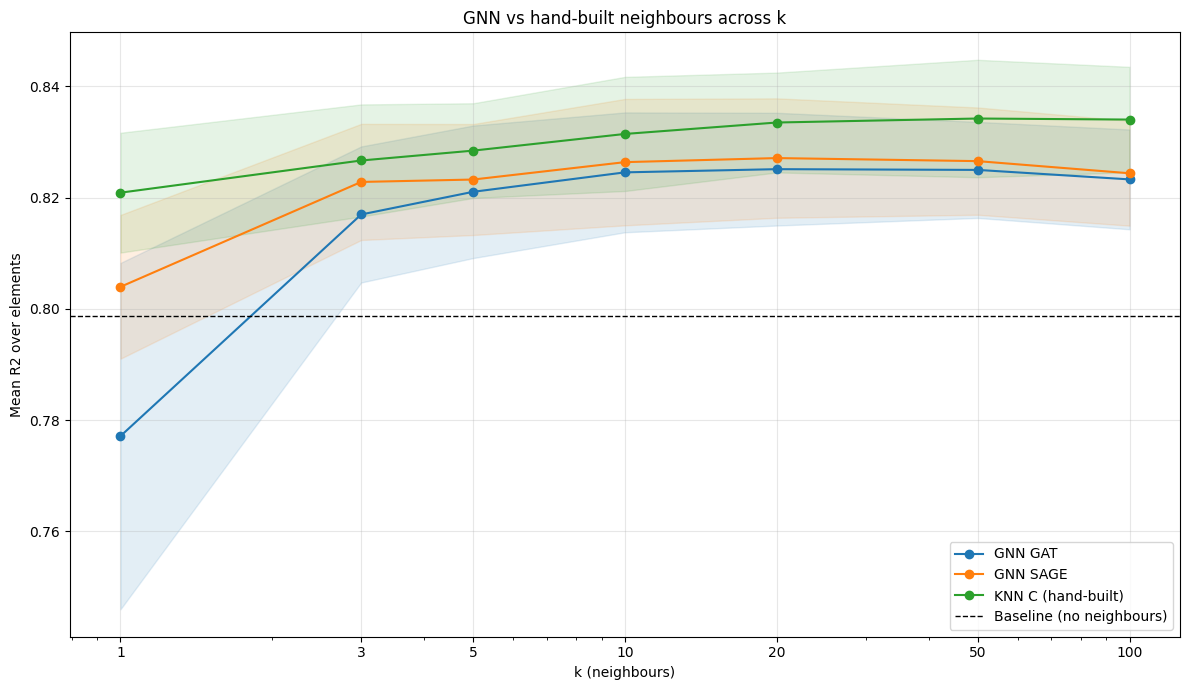

In [15]:
def LoadIfPresent(path: str, baseName: str) -> dict:
    """LoadResults announces every miss, which is noise for a sweep that is only part-run."""
    return LoadResults(path, baseName) if os.path.exists(f"{DRIVE_PATH}{path}{baseName}.json") else None


def CollectSweep(sweeps: list[int], series: dict[str, str]) -> dict[str, dict[int, dict]]:
    """{series name: {k: aggregated results}}, skipping any k that was never run."""

    collected = {}
    for name, template in series.items():
        points = {k: LoadIfPresent(RESULTS_PATH, template.format(k=k)) for k in sweeps}
        collected[name] = {k: results for k, results in points.items() if results is not None}

    return collected


def DisplaySweepGraph(series: dict[str, dict[int, dict]], baseline: dict = None, metric: str = "r2", title: str = "GNN vs hand-built neighbours across k"):

    fig, ax = plt.subplots(figsize=(12, 7))

    for name, points in series.items():
        if not points:
            continue

        ks = sorted(points)
        means, stds = [], []
        for k in ks:
            aggregated = points[k]
            scores = [s[metric] for s in aggregated.values() if s[metric] is not None]
            #Fold spread averaged over elements, so the band shows run-to-run noise
            spread = [s["r2_std"] for s in aggregated.values() if s.get("r2_std") is not None]
            means.append(np.mean(scores))
            stds.append(np.mean(spread) if spread else 0.0)

        means, stds = np.array(means), np.array(stds)

        #A single measured k has no line to draw, so mark the point instead
        line, = ax.plot(ks, means, "o" if len(ks) == 1 else "o-", label=name)
        ax.fill_between(ks, means - stds, means + stds, alpha=0.12, color=line.get_color())

    #Without the no-neighbour baseline the vertical scale means very little
    if baseline is not None:
        scores = [s[metric] for s in baseline.values() if s[metric] is not None]
        ax.axhline(np.mean(scores), color="black", linestyle="--", linewidth=1, label="Baseline (no neighbours)")

    #k values are spaced geometrically, so a linear axis would bunch everything below 20
    ax.set_xscale("log")
    ax.set_xticks(SWEEPS, [str(k) for k in SWEEPS])
    ax.set_xlabel("k (neighbours)")
    ax.set_ylabel(f"Mean {metric.upper()} over elements")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


#The hand-built curve is the bar the GNN has to clear, so it goes on the same axes.
#Variant C is the encoding the k-sweep settled on: pooling beats enumerating.
sweepSeries = {f"GNN {name}": f"GNN_{name}_KFold_k{{k}}{CHANNEL_SUFFIX}" for name in GNN_VARIANTS}

#The earlier target-blind runs stay on the plot for contrast: the gap between them and the
#target-channel curves is exactly what the neighbours' target values are worth
# if CHANNEL_SUFFIX:
#     sweepSeries["GNN SAGE (target-blind)"] = "GNN_SAGE_KFold_k{k}"
#     sweepSeries["GNN GAT (target-blind)"] = "GNN_GAT_KFold_k{k}"
sweepSeries["KNN C (hand-built)"] = "K-Sweep_{k}_C"

collectedSweep = CollectSweep(SWEEPS, sweepSeries)

for name, points in collectedSweep.items():
    print(f"{name:<22} k = {sorted(points) if points else 'none found'}")

#Named outright rather than built from MODEL_NAMES: those constants live in the Results
#section below, which runs after this cell
BASELINE_RESULTS = "HistGradientBoosting_KFold"

DisplaySweepGraph(collectedSweep, baseline=LoadIfPresent(RESULTS_PATH, BASELINE_RESULTS))

### The Settled Configuration

The sweep settles two choices. **k = 20**, where every curve flattens and past which GAT
actively degrades; and **SAGE**, which matches GAT at small k and beats it by a widening
margin above k=10 — distance-aware attention does not pay once the neighbourhood is large.

Everything below runs that one configuration against the same 71-target set the tabular
notebook uses (`coverage >= 1000`), so the GNN drops straight into those tables.

In [ ]:
SETTLED_K = 20
SETTLED_LAYER = "sage"
SETTLED_NAME = "SAGE"

#Same 71 targets as the tabular ablation, so the two notebooks compare row for row
SETTLED_BASENAME = f"GNN_{SETTLED_NAME}_KFold_k{SETTLED_K}_Cov1000{CHANNEL_SUFFIX}"

print(f"{len(elementsToTrain)} targets x {len(kfold_splits)} folds = "
      f"{len(elementsToTrain) * len(kfold_splits)} fits at k={SETTLED_K}")

results_gnn_settled = LoadResults(RESULTS_PATH, SETTLED_BASENAME)
if results_gnn_settled is None:
    raw = TrainAllElementsKFoldGNN(df, kfold_splits, elementsToTrain, elementCols,
                                   k=SETTLED_K, layerType=SETTLED_LAYER,
                                   includeTargetChannel=TARGET_CHANNEL)
    results_gnn_settled = AggregateFolds(raw)
    SaveResults(results_gnn_settled, RESULTS_PATH, SETTLED_BASENAME)

scored = [s["r2"] for s in results_gnn_settled.values() if s["r2"] is not None]
print(f"{SETTLED_NAME} k={SETTLED_K}, {len(scored)} targets scored, mean R2 {np.mean(scored):.4f}")

### Feature Set Combinations

The same ablation as the tabular notebook, with one difference that has to be stated rather
than assumed: **the graph is always on**. A GNN cannot drop its neighbourhood the way the
tabular `Neighbours` row dropped own chemistry, so every set below is *those node features
plus the k=20 neighbourhood*. The GNN `Chemistry` row is therefore the counterpart of the
tabular `KNN C` row, not of the tabular `Chemistry` row.

That also means there is no GNN equivalent of the tabular `Neighbours`-only set — the closest
thing is `Physics`, which is the honest RQ2 row: no own chemistry, only fields that exist
everywhere, plus whatever the neighbourhood carries.

In [ ]:
#Node feature sets. The k=20 neighbourhood is added to every one of them by the graph itself
GNN_FEATURE_SETS = {
    "Chemistry":            elementCols,
    "Chemistry + Physics":  elementCols + physicalCols,
    "Chemistry + Location": elementCols + locationCols,
    "Physics":              physicalCols,
    "Location":             locationCols,
    "Physics + Location":   physicalCols + locationCols,
}

#Ordered most-informative first, and each set is cached on completion, so a run that is
#stopped part way still answers the main question and resumes where it left off
FEATURE_SETS_TO_RUN = ["Chemistry", "Chemistry + Physics", "Chemistry + Location"]


def FeatureSetBaseName(name: str) -> str:
    #Chemistry is the settled run itself, so it reuses that file rather than training twice
    if name == "Chemistry":
        return SETTLED_BASENAME
    return f"{SETTLED_BASENAME}_FeatureSet_{name.replace(' + ', '_')}"


results_gnn_features = {}

for name in FEATURE_SETS_TO_RUN:
    baseName = FeatureSetBaseName(name)

    results_gnn_features[name] = LoadResults(RESULTS_PATH, baseName)
    if results_gnn_features[name] is None:
        print(f"Training {name} ({len(GNN_FEATURE_SETS[name])} node columns)...")
        raw = TrainAllElementsKFoldGNN(df, kfold_splits, elementsToTrain, GNN_FEATURE_SETS[name],
                                       k=SETTLED_K, layerType=SETTLED_LAYER,
                                       includeTargetChannel=TARGET_CHANNEL)
        results_gnn_features[name] = AggregateFolds(raw)
        SaveResults(results_gnn_features[name], RESULTS_PATH, baseName)

    print(f"{name:<22} ready")

In [35]:
def ReportGNNvsTabular(gnnResults: dict[str, dict], tabularResults: dict[str, dict], reference: str):
    """Both notebooks on one table, scored against the tabular own-chemistry baseline."""

    everything = {f"tabular {name}": results for name, results in tabularResults.items()}
    everything.update({f"GNN {name}": results for name, results in gnnResults.items()})

    referenceScore = np.mean([s["r2"] for s in tabularResults[reference].values() if s["r2"] is not None])

    printable = Printable()
    printable.title(f"Mean R2 over {len(elementsToTrain)} targets")
    for name, results in everything.items():
        scores = [s["r2"] for s in results.values() if s["r2"] is not None]
        spreads = [s["r2_std"] for s in results.values() if s.get("r2_std") is not None]
        if not scores:
            continue
        printable.add(name, f"R2: {np.mean(scores):.4f} +/- {np.mean(spreads):.4f}"
                            f"   vs tabular {reference}: {np.mean(scores) - referenceScore:>+7.4f}")
    printable.flush()

    return everything


#Pulled off disk so the GNN is scored against exactly the numbers the tabular notebook reported
tabularResults = {
    "Chemistry": LoadIfPresent(RESULTS_PATH, "HistGradientBoosting_KFold_FeatureSet_Chemistry_Cov1000"),
    "Chemistry + Physics": LoadIfPresent(RESULTS_PATH, "HistGradientBoosting_KFold_FeatureSet_Chemistry_Physics_Cov1000"),
    "KNN C": LoadIfPresent(RESULTS_PATH, "HistGradientBoosting_KFold_KNN_C_ExcludingColocation_Cov1000"),
}
tabularResults = {name: results for name, results in tabularResults.items() if results is not None}

allResults = ReportGNNvsTabular(results_gnn_features, tabularResults, reference="Chemistry")

============================= Mean R2 over 71 targets =============================
tabular Chemistry:             R2: 0.8676 +/- 0.0137   vs tabular Chemistry: +0.0000
tabular Chemistry + Physics:   R2: 0.8739 +/- 0.0129   vs tabular Chemistry: +0.0063
tabular KNN C:                 R2: 0.8801 +/- 0.0132   vs tabular Chemistry: +0.0125
GNN Chemistry:                 R2: 0.8676 +/- 0.0129   vs tabular Chemistry: -0.0000
GNN Chemistry + Physics:       R2: 0.8679 +/- 0.0132   vs tabular Chemistry: +0.0004
GNN Chemistry + Location:      R2: 0.8684 +/- 0.0133   vs tabular Chemistry: +0.0008


### Per-Element Detail

The pooled table says which configuration wins on average; this one says *where*. The
comparison that matters is against the hand-built `KNN C`, not against the no-neighbour
baseline: the GNN has to beat the encoding it replaces, not merely the one it improves on.

Both reference rows are the `Cov1000` files, so every column covers the same 71 targets.

In [36]:
MODEL_NAMES = { "rf": "RandomForest", "hgb": "HistGradientBoosting", "xgb": "XGBoost" }
MODEL_TYPE = "hgb"

BASELINE_NAME = "Baseline (no neighbours)"
HANDBUILT_NAME = "KNN C (hand-built)"

#The Cov1000 references, so the tabular columns cover the same 71 targets as the GNN ones
REFERENCE_SETS = {
    BASELINE_NAME:  f"{MODEL_NAMES[MODEL_TYPE]}_KFold_FeatureSet_Chemistry_Cov1000",
    HANDBUILT_NAME: f"{MODEL_NAMES[MODEL_TYPE]}_KFold_KNN_C_ExcludingColocation_Cov1000",
}


def ReportGNN(gnnResults: dict[str, dict], elements: list[str]):
    """Per-element table of the settled GNN against the tabular numbers already reported."""

    reference = {name: LoadIfPresent(RESULTS_PATH, baseName) for name, baseName in REFERENCE_SETS.items()}

    allResults = { name: results for name, results in reference.items() if results is not None }
    allResults.update({ f"GNN {name}": results for name, results in gnnResults.items() })

    #A missing reference file should cost the delta column, not the whole table
    baseline = allResults.get(BASELINE_NAME)
    baselineScore = np.mean([s["r2"] for s in baseline.values() if s["r2"] is not None]) if baseline else float("nan")

    printable = Printable()
    printable.title(f"Mean R2 over {len(elements)} targets")
    for name, results in allResults.items():
        scores = [s["r2"] for s in results.values() if s["r2"] is not None]
        spreads = [s["r2_std"] for s in results.values() if s.get("r2_std") is not None]
        printable.add(name, f"R2: {np.mean(scores):.4f} +/- {np.mean(spreads):.4f}   vs baseline: {np.mean(scores) - baselineScore:>+7.4f}")

    printable.rest()
    printable.title("Per Element")
    printable.add("element", " ".join(f"{name[:13]:>13}" for name in allResults))
    for element in elements:
        cells = []
        for name in allResults:
            score = allResults[name].get(element, {}).get("r2")
            cells.append(f"{score:>13.3f}" if score is not None else f"{'-':>13}")
        printable.add(element, " ".join(cells))

    printable.flush()

    return allResults


allResults = ReportGNN(results_gnn_features, elementsToTrain)

============================== Mean R2 over 71 targets ==============================
Baseline (no neighbours):   R2: 0.8676 +/- 0.0137   vs baseline: +0.0000
KNN C (hand-built):         R2: 0.8801 +/- 0.0132   vs baseline: +0.0125
GNN Chemistry:              R2: 0.8676 +/- 0.0129   vs baseline: -0.0000
GNN Chemistry + Physics:    R2: 0.8679 +/- 0.0132   vs baseline: +0.0004
GNN Chemistry + Location:   R2: 0.8684 +/- 0.0133   vs baseline: +0.0008


============================== Per Element ==============================
element:                    Baseline (no  KNN C (hand-b GNN Chemistry GNN Chemistry GNN Chemistry
SiO2 wt%:                           0.985         0.984         0.960         0.957         0.962
TiO2 wt%:                           0.930         0.938         0.935         0.932         0.933
Al2O3 wt%:                          0.975         0.975         0.971         0.969         0.969
Fe2O3t wt%:                         0.962         0.964         0.957         0.9

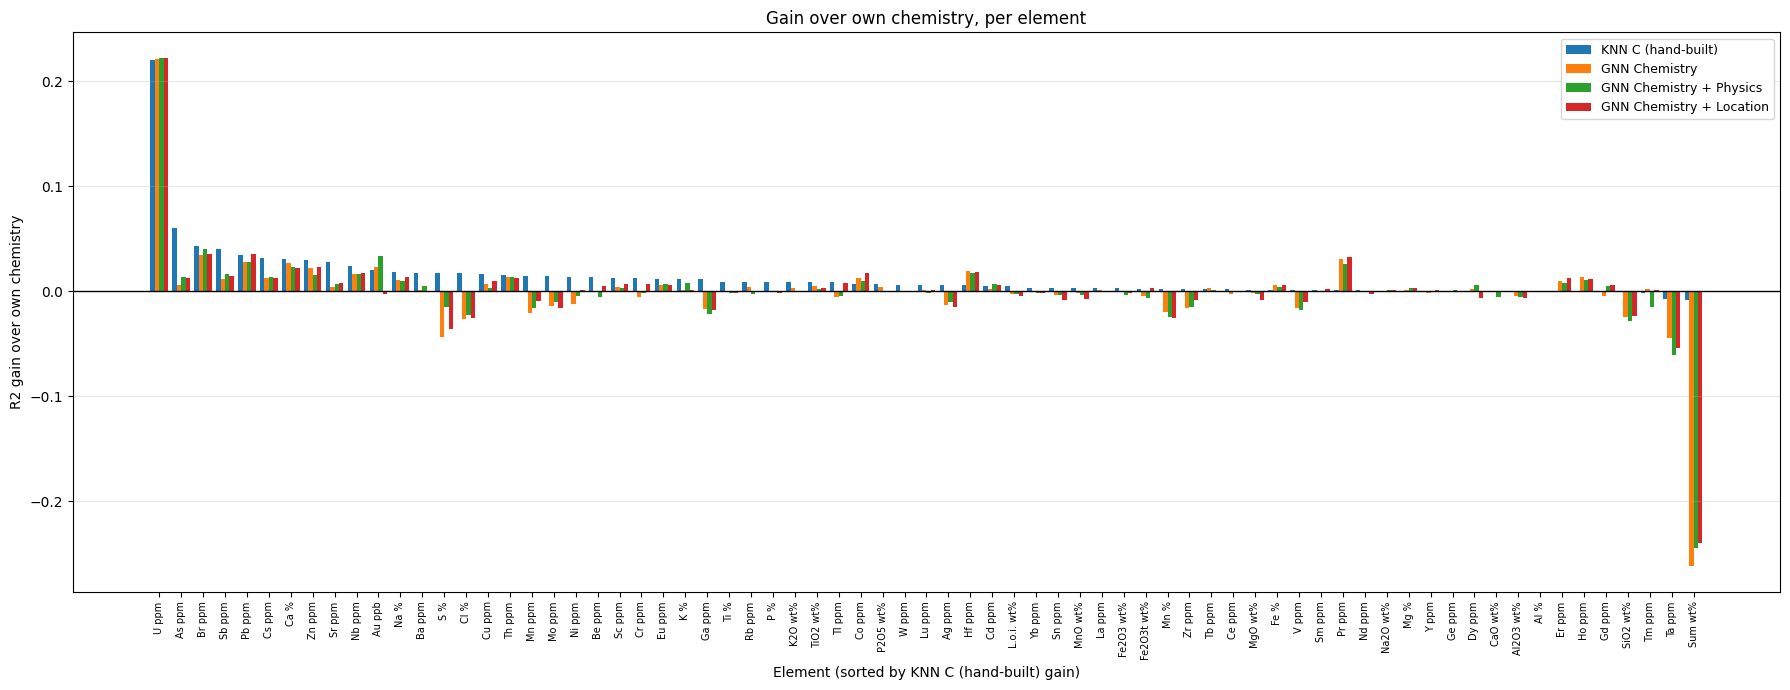

In [37]:
def DisplayGNNGains(allResults: dict[str, dict], elements: list[str], baselineName: str = BASELINE_NAME, sortBy: str = HANDBUILT_NAME, title: str = "Gain over own chemistry, per element"):
    """71 raw bars per series is unreadable, so this plots the gain and sorts by one series."""

    baseline = allResults[baselineName]
    series = {name: results for name, results in allResults.items() if name != baselineName}

    def Gain(results, element):
        score = results.get(element, {}).get("r2")
        reference = baseline.get(element, {}).get("r2")
        return score - reference if score is not None and reference is not None else np.nan

    #Sorting by the hand-built gain lets the GNN series be read against it element by element
    key = sortBy if sortBy in series else list(series)[0]
    ordered = sorted(elements, key=lambda e: (np.isnan(Gain(series[key], e)), -Gain(series[key], e)))

    x = np.arange(len(ordered))
    width = 0.8 / len(series)

    fig, ax = plt.subplots(figsize=(18, 7))

    for i, (name, results) in enumerate(series.items()):
        offset = (i - (len(series) - 1) / 2) * width
        ax.bar(x + offset, [Gain(results, e) for e in ordered], width, label=name)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x, ordered, rotation=90, fontsize=7)
    ax.set_xlabel(f"Element (sorted by {key} gain)")
    ax.set_ylabel("R2 gain over own chemistry")
    ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


DisplayGNNGains(allResults, elementsToTrain)